# Category Quantization

This notebook loads per-video embeddings from Google Drive, optimizes a per-channel k-means model (4 to 10 clusters, bounded by available samples), and visualizes the clusters for a selected channel using a scatter plot and a labeled table.

## 1) Mount Google Drive and load channel video embeddings

This cell mounts Drive (for Colab use), reads the embedding dataset, and validates that required columns are present. The notebook uses `channel_name` as the primary label, following Graphiko coding guidelines.

In [3]:
from __future__ import annotations

# If running in Google Colab, mount Drive. In local/Jupyter environments this section is skipped.
try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
except Exception:
    pass

import ast
import json
from pathlib import Path

import numpy as np
import pandas as pd

# Follow documented export path from docs/Graphiko/fetch_videos_embeddings_analysis.md.
DATA_PATH = Path(
    '/content/drive/MyDrive/Graphiko/exports/video_embeddings_reduced/latest/'
    'business_cluster_video_embeddings_reduced_20d.csv'
)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'Embedding file not found at documented path: {DATA_PATH}. '
        'Update DATA_PATH only if your export was intentionally written elsewhere.'
    )

if DATA_PATH.suffix.lower() == '.parquet':
    videos_df = pd.read_parquet(DATA_PATH)
elif DATA_PATH.suffix.lower() == '.csv':
    videos_df = pd.read_csv(DATA_PATH)
else:
    raise ValueError(f'Unsupported input format: {DATA_PATH.suffix}')

videos_df = videos_df.copy()
videos_df['video_title'] = videos_df.get('video_title', '').astype(str)

if 'channel_name' not in videos_df.columns:
    if 'channel_id' in videos_df.columns:
        videos_df['channel_name'] = videos_df['channel_id'].astype(str)
    else:
        raise ValueError('Missing channel_name (or channel_id fallback) in input data.')

if 'video_url' not in videos_df.columns:
    if 'video_id' in videos_df.columns:
        videos_df['video_url'] = videos_df['video_id'].map(
            lambda vid: f'https://www.youtube.com/watch?v={vid}'
        )
    else:
        videos_df['video_url'] = ''

embedding_columns = sorted(
    [c for c in videos_df.columns if c.startswith('embedding_reduced_')]
)

def to_embedding_array(value) -> np.ndarray:
    """Normalize serialized embedding values into a 1D float numpy array."""
    if isinstance(value, np.ndarray):
        return value.astype(float)
    if isinstance(value, list):
        return np.asarray(value, dtype=float)
    if isinstance(value, str):
        parsed = None
        try:
            parsed = json.loads(value)
        except json.JSONDecodeError:
            parsed = ast.literal_eval(value)
        return np.asarray(parsed, dtype=float)
    raise TypeError(f'Unsupported embedding type: {type(value)}')

if 'embedding' in videos_df.columns:
    videos_df['embedding_array'] = videos_df['embedding'].map(to_embedding_array)
elif embedding_columns:
    videos_df['embedding_array'] = videos_df[embedding_columns].astype(float).to_numpy().tolist()
    videos_df['embedding_array'] = videos_df['embedding_array'].map(lambda row: np.asarray(row, dtype=float))
else:
    raise ValueError(
        'Missing embedding columns. Expected either "embedding" or "embedding_reduced_XX" columns.'
    )

videos_df['channel_name'] = videos_df['channel_name'].astype(str)

print(f'Loaded {len(videos_df):,} videos across {videos_df["channel_name"].nunique():,} channels.')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 1,344 videos across 27 channels.


## 2) Train per-channel k-means with dynamic cluster count

This cell chooses the best cluster count per channel by maximizing silhouette score between 4 and 10 clusters (subject to sample constraints), then stores fitted models and assignments.

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def optimize_channel_kmeans(
    df: pd.DataFrame,
    min_k: int = 4,
    max_k: int = 10,
    random_state: int = 42,
) -> tuple[pd.DataFrame, dict[str, dict]]:
    """Train a k-means model for each channel using silhouette-based k optimization."""
    channel_results: list[pd.DataFrame] = []
    channel_models: dict[str, dict] = {}

    for channel_name, channel_df in df.groupby('channel_name', sort=True):
        X = np.stack(channel_df['embedding_array'].to_list())
        n_samples = X.shape[0]

        candidate_min = min(min_k, max(2, n_samples - 1))
        candidate_max = min(max_k, n_samples - 1)

        if candidate_max < 2:
            labeled = channel_df.copy()
            labeled['cluster_id'] = 0
            labeled['cluster_name'] = f'{channel_name} | Category 1'
            channel_results.append(labeled)
            channel_models[channel_name] = {
                'best_k': 1,
                'model': None,
                'silhouette_score': np.nan,
            }
            continue

        candidate_ks = list(range(max(2, candidate_min), candidate_max + 1))
        best_model = None
        best_score = -1.0
        best_k = candidate_ks[0]

        for k in candidate_ks:
            model = KMeans(n_clusters=k, random_state=random_state, n_init='auto')
            labels = model.fit_predict(X)
            score = silhouette_score(X, labels)
            if score > best_score:
                best_model = model
                best_score = score
                best_k = k

        assert best_model is not None
        labeled = channel_df.copy()
        labeled['cluster_id'] = best_model.labels_
        labeled['cluster_name'] = labeled['cluster_id'].map(
            lambda cid: f'{channel_name} | Category {int(cid) + 1}'
        )
        channel_results.append(labeled)
        channel_models[channel_name] = {
            'best_k': best_k,
            'model': best_model,
            'silhouette_score': best_score,
        }

    clustered_df = pd.concat(channel_results, ignore_index=True)
    return clustered_df, channel_models


clustered_videos_df, channel_cluster_models = optimize_channel_kmeans(videos_df)

summary_df = (
    pd.DataFrame(
        [
            {
                'channel_name': channel,
                'best_k': data['best_k'],
                'silhouette_score': data['silhouette_score'],
            }
            for channel, data in channel_cluster_models.items()
        ]
    )
    .sort_values(['best_k', 'silhouette_score'], ascending=[False, False])
    .reset_index(drop=True)
)
summary_df.head(20)

,channel_name,best_k,silhouette_score
0,Principles by Ray Dalio,10,0.275160
1,Real Vision Presents,9,0.204045
2,Alex Hormozi,9,0.148905
3,Greg Isenberg,9,0.121207
4,Asianometry,8,0.130287
5,a16z,8,0.097063
6,The Prof G Pod – Scott Galloway,7,0.148836
7,Patrick Boyle,7,0.128162
8,Anthony Pompliano,6,0.113547
9,Y Combinator,6,0.098182


## 3) Visualize clusters for a selected channel ("polygon")

This function reduces embeddings to 2D, plots videos as dots colored by cluster, and returns a table with video names and their assigned category labels. The example uses the first channel in alphabetical order.

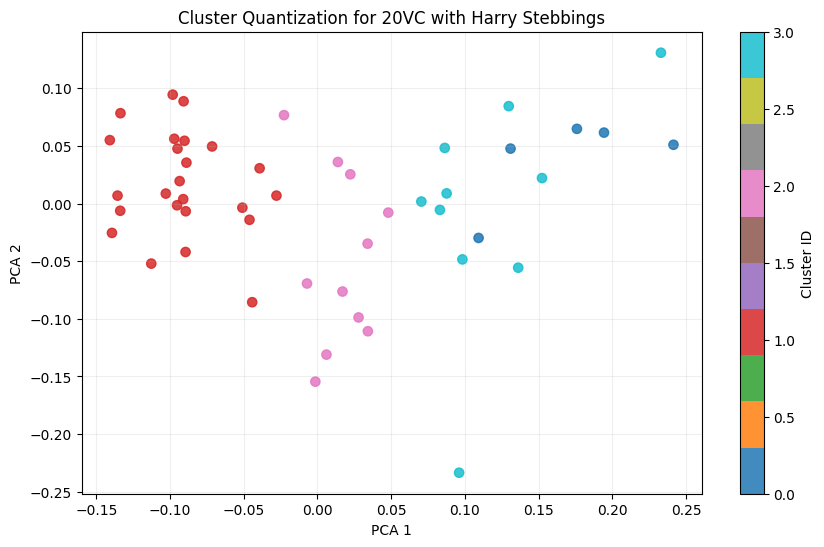

,channel_name,video_title,video_url,cluster_id,cluster_name
0,20VC with Harry Stebbings,"""Cursor is Dead"" is Total BS: Here is Why | Mi...",https://www.youtube.com/watch?v=3KsjuNcxTYA,0,20VC with Harry Stebbings | Category 1
1,20VC with Harry Stebbings,Mitchell Green: Why 50% of VCs Should Not Exist,https://www.youtube.com/watch?v=rPaWW0IDurI,0,20VC with Harry Stebbings | Category 1
2,20VC with Harry Stebbings,Oren Zeev: 50% of Funds Will Go Out of Busines...,https://www.youtube.com/watch?v=KuurCxYog5k,0,20VC with Harry Stebbings | Category 1
3,20VC with Harry Stebbings,This is why I don't believe in sales quotas | ...,https://www.youtube.com/watch?v=5klhxOKZ_ag,0,20VC with Harry Stebbings | Category 1
4,20VC with Harry Stebbings,Why Margins Don't Matter for Early-Stage Start...,https://www.youtube.com/watch?v=LCLzgK03CQ0,0,20VC with Harry Stebbings | Category 1
5,20VC with Harry Stebbings,Anthropic Inference Costs Skyrocket |TikTok De...,https://www.youtube.com/watch?v=AkObfvN3ArI,1,20VC with Harry Stebbings | Category 2
6,20VC with Harry Stebbings,Anthropic Raises $30B from Microsoft & NVIDIA ...,https://www.youtube.com/watch?v=U1sy7t_Wns8,1,20VC with Harry Stebbings | Category 2
7,20VC with Harry Stebbings,Anthropic vs The Pentagon: Who Wins? | Cursor ...,https://www.youtube.com/watch?v=7RHwE_M68BY,1,20VC with Harry Stebbings | Category 2
8,20VC with Harry Stebbings,Anthropic vs The Pentagon: Who Wins? | The Dat...,https://www.youtube.com/watch?v=R8YC8OCnDxM,1,20VC with Harry Stebbings | Category 2
9,20VC with Harry Stebbings,Anthropic's Super Bowl Ad: Who Won & Lost? | S...,https://www.youtube.com/watch?v=RdunfbobxaY,1,20VC with Harry Stebbings | Category 2


In [5]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


def display_polygon_clusters(
    clustered_df: pd.DataFrame,
    polygon_name: str,
    point_size: int = 45,
) -> pd.DataFrame:
    """Plot cluster scatter and return a labeled video table for one channel/polygon."""
    polygon_df = clustered_df.loc[clustered_df['channel_name'] == polygon_name].copy()
    if polygon_df.empty:
        raise ValueError(f'No videos found for polygon/channel: {polygon_name}')

    X = np.stack(polygon_df['embedding_array'].to_list())
    coords = PCA(n_components=2, random_state=42).fit_transform(X)
    polygon_df['x'] = coords[:, 0]
    polygon_df['y'] = coords[:, 1]

    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(
        polygon_df['x'],
        polygon_df['y'],
        c=polygon_df['cluster_id'],
        cmap='tab10',
        s=point_size,
        alpha=0.85,
    )
    plt.title(f'Cluster Quantization for {polygon_name}')
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.grid(alpha=0.2)
    plt.colorbar(scatter, label='Cluster ID')
    plt.show()

    table_df = (
        polygon_df[
            ['channel_name', 'video_title', 'video_url', 'cluster_id', 'cluster_name']
        ]
        .sort_values(['cluster_id', 'video_title'])
        .reset_index(drop=True)
    )
    return table_df


# Example: display one polygon/channel.
example_polygon = sorted(clustered_videos_df['channel_name'].unique())[0]
example_table = display_polygon_clusters(clustered_videos_df, example_polygon)
example_table.head(25)